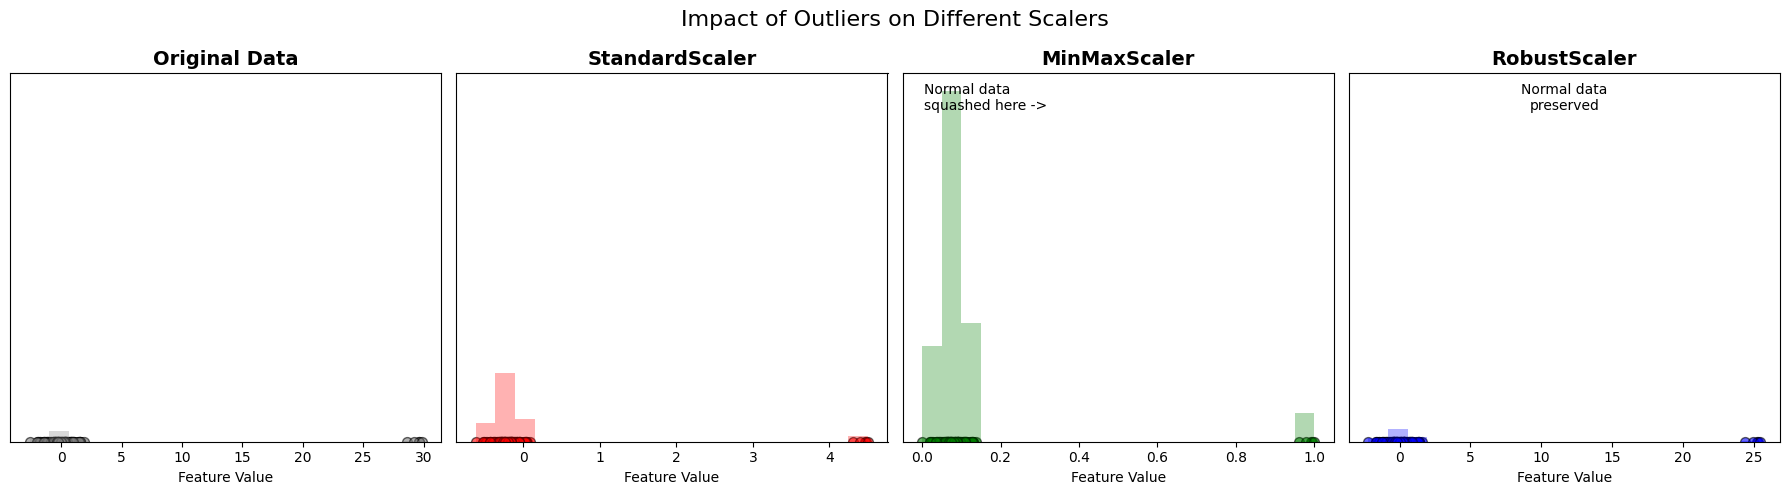

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 1. Create a dataset with normal data and outliers
np.random.seed(42)
# Generate 100 normal points centered around 0
X_normal = np.random.normal(loc=0.0, scale=1.0, size=100)
# Add 5 extreme outliers
X_outliers = np.random.normal(loc=30.0, scale=1.0, size=5)
X = np.concatenate([X_normal, X_outliers]).reshape(-1, 1)

# 2. Initialize Scalers
scalers = {
    "Original Data": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

# 3. Plotting
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Impact of Outliers on Different Scalers', fontsize=16)

colors = ['grey', 'red', 'green', 'blue']

for ax, (name, scaler), color in zip(axes, scalers.items(), colors):
    if scaler:
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X
        
    # Scatter plot to show individual points
    ax.scatter(X_scaled, np.zeros_like(X_scaled), color=color, alpha=0.6, s=50, edgecolors='k')
    
    # Histogram to show density/distribution
    ax.hist(X_scaled, bins=20, color=color, alpha=0.3, density=True)
    
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature Value')
    
    # Remove y-axis ticks as they are arbitrary for 1D scatter
    ax.set_yticks([])

    # Highlight the specific behavior
    if name == "MinMaxScaler":
        ax.text(0.05, 0.9, "Normal data\nsquashed here ->", transform=ax.transAxes, color='black', fontsize=10)
    elif name == "RobustScaler":
        ax.text(0.5, 0.9, "Normal data\npreserved", transform=ax.transAxes, color='black', fontsize=10, ha='center')

plt.tight_layout()
plt.show()